In [ ]:
# from autocvd import autocvd
# autocvd(num_gpus = 1, interval=1)
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '5'

import numpy as np
import matplotlib.pyplot as plt
import time 
from functools import partial  # Change this line - lowercase 'partial'

import jax.numpy as jnp
import jax
from jax import jit

# jax.config.update("jax_enable_x64", True)
from jax.sharding import Mesh, PartitionSpec, NamedSharding         #IMPORT NEEDED FOR AUTOMATIC PARALLELISM
from jax.experimental import shard_map



import pandas as pd
import seaborn as sns
from chainconsumer import Chain, ChainConsumer, Truth



from odisseo import construct_initial_state
from odisseo.dynamics import  DIRECT_ACC_MATRIX, DIRECT_ACC_LAXMAP
from odisseo.option_classes import SimulationConfig, SimulationParams, MNParams, NFWParams, PlummerParams, PSPParams, MN_POTENTIAL, NFW_POTENTIAL, PSP_POTENTIAL
from odisseo.initial_condition import Plummer_sphere
from odisseo.time_integration import time_integration
from odisseo.units import CodeUnits
from odisseo.utils import projection_on_GD1
from astropy import units as u
import blackjax
from tqdm import tqdm


code_length = 10.0 * u.kpc
code_mass = 1e4 * u.Msun
code_time = 3 * u.Gyr
code_units = CodeUnits(code_length, code_mass, G=1, unit_time = code_time )  
N_particles = 1000

pos_com_final = jnp.array([[11.8, 0.79, 6.4]]) * u.kpc.to(code_units.code_length)
vel_com_final = jnp.array([[109.5,-254.5,-90.3]]) * (u.km/u.s).to(code_units.code_velocity)

config_sim = SimulationConfig(N_particles = N_particles,
                            return_snapshots = False, 
                            num_timesteps = 1000, 
                            external_accelerations=(NFW_POTENTIAL, MN_POTENTIAL, PSP_POTENTIAL), 
                            acceleration_scheme = DIRECT_ACC_MATRIX,
                            softening = (0.1 * u.pc).to(code_units.code_length).value,) #default values
        #the center of mass needs to be integrated backwards in time first 
config_com = config_sim._replace(N_particles=1,)

@jit
def run_simulation(rng_key, params):
    params_samples = SimulationParams(t_end = params['t_end'] * u.Gyr.to(code_units.code_time),
                        Plummer_params = PlummerParams(Mtot=params['Mtot'] * u.Msun.to(code_units.code_mass),
                                                       a = params['a_Plummer'] * u.kpc.to(code_units.code_length),),
                        NFW_params = NFWParams(Mvir=params['M_NFW'] * u.Msun.to(code_units.code_mass),
                                               r_s= params['r_s'] * u.kpc.to(code_units.code_length)),
                        MN_params = MNParams(M = params['M_MN'] * u.Msun.to(code_units.code_mass),
                                             a = params['a_MN'] * u.kpc.to(code_units.code_length),
                                            b = (0.280 * u.kpc).to(code_units.code_length).value),
                        PSP_params= PSPParams(M = 4501365375.06545 * u.Msun.to(code_units.code_mass),
                                                alpha = 1.8, 
                                                r_c = (1.9*u.kpc).to(code_units.code_length).value),  
                        G = code_units.G, )

    params_com = params_samples._replace(t_end=-params_samples.t_end,)
    mass_com = jnp.array([params_samples.Plummer_params.Mtot]) 
    
    #we construmt the initial state of the com 
    initial_state_com = construct_initial_state(pos_com_final, vel_com_final,)
    #we run the simulation backwards in time for the center of mass
    final_state_com = time_integration(initial_state_com, mass_com, config=config_com, params=params_com)
    #we calculate the final position and velocity of the center of mass
    pos_com = final_state_com[:, 0]
    vel_com = final_state_com[:, 1]

    #we construct the initial state of the Plummer sphere
    positions, velocities, mass = Plummer_sphere(key=rng_key, params=params_samples, config=config_sim)
    #we add the center of mass position and velocity to the Plummer sphere particles
    positions = positions + pos_com
    velocities = velocities + vel_com
    #initialize the initial state
    initial_state_stream = construct_initial_state(positions, velocities, )
    #run the simulation
    final_state = time_integration(initial_state_stream, mass, config=config_sim, params=params_samples)

    #projection on the GD1 stream
    stream = projection_on_GD1(final_state, code_units=code_units,)

    return stream

def log_diag_multivariate_normal(x, mean, sigma):
        """
        Log PDF of a multivariate Gaussian with diagonal covariance.
        
        Parameters
        ----------
        x : (D,)
        mean : (D,)
        sigma : (D,)  # standard deviations for each dimension
        """
        diff = (x - mean) / sigma
        D = x.shape[0]
        log_det = 2.0 * jnp.sum(jnp.log(sigma))
        norm_const = -0.5 * (D * jnp.log(2 * jnp.pi) + log_det)
        exponent = -0.5 * jnp.sum(diff**2)
        return norm_const + exponent

# @jit
# def stream_likelihood(model_stream, obs_stream, obs_errors, ):
#     """
#     Log-likelihood of observed stars given simulated stream (diagonal covariance).
    
#     Parameters
#     ----------
#     model_stream : (N_model, D)
#     obs_stream : (N_obs, D)
#     obs_errors : (N_obs, D)   # per-dimension standard deviations
#     tau : float
#         Stream membership fraction
#     p_field : float
#         Background probability density
#     """
#     def obs_log_prob(obs, sigma):
#         def model_log_prob(model_point):
#             return log_diag_multivariate_normal(obs, model_point, sigma)

#         # Compute log_probs for all model points
#         log_probs = jax.vmap(model_log_prob)(model_stream)
        
#         # Numerically stable average: log(mean(exp(log_probs)))
#         log_p_stream = jax.scipy.special.logsumexp(log_probs) - jnp.log(model_stream.shape[0])
        
#         # Mixture model
#         # p_total = tau * jnp.exp(log_p_stream) + (1 - tau) * p_field
#         p_total = jnp.exp(log_p_stream)
#         return jnp.log(p_total + 1e-30)

#     # Vectorize over observations
#     logL_values = jax.vmap(obs_log_prob)(obs_stream, jnp.repeat(obs_errors, obs_stream.shape[0]).reshape(-1, 6))
#     return jnp.sum(logL_values)




# @jit
def stream_likelihood(model_stream, obs_stream, ):
    @jit
    def rbf_kernel(x, y, sigma):
        """RBF kernel optimized for 6D astronomical data"""
        return jnp.exp(-jnp.sum((x - y)**2) / (2 * sigma**2))

    @jit 
    def compute_mmd(sim_norm, target_norm, sigmas):
        xx = jnp.mean(jax.vmap(lambda xi: jax.vmap(lambda xj: rbf_kernel(xi, xj, sigmas))(sim_norm))(sim_norm))
        yy = jnp.mean(jax.vmap(lambda yi: jax.vmap(lambda yj: rbf_kernel(yi, yj, sigmas))(target_norm))(target_norm))
        xy = jnp.mean(jax.vmap(lambda xi: jax.vmap(lambda yj: rbf_kernel(xi, yj, sigmas))(target_norm))(sim_norm))
        return xx + yy - 2 * xy

    distances = jax.vmap(lambda x: jax.vmap(lambda y: jnp.linalg.norm(x - y))(model_stream))(obs_stream)
    distance_flat = distances.flatten()
    # # Use percentiles as natural scales
    sigmas = jnp.array([
        jnp.percentile(distance_flat, 10),   # Fine scale
        jnp.percentile(distance_flat, 25),   # Small scale  
        jnp.percentile(distance_flat, 50),   # Medium scale (median)
        # jnp.percentile(distance_flat, 75),   # Large scale
        # jnp.percentile(distance_flat, 90),   # Very large scale
    ])

    # Adaptive weights based on scale separation
    # scale_weights = jnp.array([0.15, 0.2, 0.3, 0.25, 0.1])
    scale_weights = jnp.ones_like(sigmas)  # Equal weights for simplicity

    # Compute MMD with multiple kernels
    mmd_total = jnp.sum(scale_weights * jax.vmap(lambda sigma: compute_mmd(model_stream, obs_stream, sigma))(sigmas))

    # return mmd_total / (len(sigmas) * 1000)
    return -mmd_total/len(sigmas)


true_GD1_observation_path = '/export/data/vgiusepp/odisseo_data/data_fix_position/true.npz'
observation = jnp.array(np.load(true_GD1_observation_path)['x'][:1000]).reshape(1, 1000, 6)
true_theta = jnp.array(np.load(true_GD1_observation_path)['theta'][:1000])

@jit
def evaluate_loglikelihood(observation, theta_1, ):

        key = jax.random.PRNGKey(0)
        # print(f"In the corrector: theta_1 shape: {theta_1.shape}, target shape: {target.shape}")
        output = run_simulation(key, theta_1)

        return stream_likelihood(model_stream=output, obs_stream=observation,)


# True parameter values (without code_units transformation)
true_params = jnp.array([
    3.0,                    # t_end (Gyr)
    10**4.05,              # Plummer Mtot (Msun) 
    8.0 * 1e-3,            # Plummer a (kpc) - converted from pc to kpc
    4.3683325e11,          # NFW Mvir (Msun)
    16.0,                  # NFW r_s (kpc)
    68_193_902_782.346756, # MN M (Msun)
    3.0,                   # MN a (kpc)
])

# Prior bounds for each parameter
prior_bounds = jnp.array([
    [0.5, 5.0],                    # t_end: 0.5 to 5 Gyr
    [10**3, 10**4.5],              # Plummer Mtot: 10^3 to 10^4.5 Msun
    [8.0 * 1e-3 * 0.25, 8.0 * 1e-3 * 2.0],  # Plummer a: 1/4 to 2x true (kpc)
    [4.3683325e11 * 0.25, 4.3683325e11 * 2.0],  # NFW Mvir: 1/4 to 2x true
    [16.0 * 0.25, 16.0 * 2.0],    # NFW r_s: 1/4 to 2x true (kpc)
    [68_193_902_782.346756 * 0.25, 68_193_902_782.346756 * 2.0],  # MN M: 1/4 to 2x true
    [3.0 * 0.25, 3.0 * 2.0],      # MN a: 1/4 to 2x true (kpc)
])  # Shape: (7, 2) for [min, max] bounds

def draw_from_prior(key):
    """Draw samples from uniform prior."""
    key, subkey = jax.random.split(key)
    u = jax.random.uniform(subkey, shape=(7,))
    
    # Transform uniform [0,1] to [min, max] for each parameter
    samples = prior_bounds[:, 0] + u * (prior_bounds[:, 1] - prior_bounds[:, 0])
    samples = {'t_end': samples[0], 'Mtot': samples[1], 'a_Plummer': samples[2], 'M_NFW': samples[3], 'r_s': samples[4], 'M_MN': samples[5], 'a_MN': samples[6]}
    return samples

@jit
def evaluate_log_prior(theta):
    """Evaluate log prior density (uniform)."""
    # Check if all parameters are within bounds 
    # theta = jnp.array([theta['t_end'], theta['Mtot'], theta['a_Plummer'], theta['M_NFW'], theta['r_s'], theta['M_MN'], theta['a_MN']])
    # in_bounds = jnp.all((theta >= prior_bounds[:, 0]) & (theta <= prior_bounds[:, 1])) 
    in_bounds = jnp.all(jnp.array([
        (theta['t_end'] >= prior_bounds[0, 0]) & (theta['t_end'] <= prior_bounds[0, 1]),
        (theta['Mtot'] >= prior_bounds[1, 0]) & (theta['Mtot'] <= prior_bounds[1, 1]),
        (theta['a_Plummer'] >= prior_bounds[2, 0]) & (theta['a_Plummer'] <= prior_bounds[2, 1]),    
        (theta['M_NFW'] >= prior_bounds[3, 0]) & (theta['M_NFW'] <= prior_bounds[3, 1]),
        (theta['r_s'] >= prior_bounds[4, 0]) & (theta['r_s'] <= prior_bounds[4, 1]),
        (theta['M_MN'] >= prior_bounds[5, 0]) & (theta['M_MN'] <= prior_bounds[5, 1]),
        (theta['a_MN'] >= prior_bounds[6, 0]) & (theta['a_MN'] <= prior_bounds[6, 1]),
    ]))
    
    # For uniform distribution: log(density) = -log(volume)
    # Volume = product of interval widths
    log_volume = jnp.sum(jnp.log(prior_bounds[:, 1] - prior_bounds[:, 0]))
    
    # Return -inf if out of bounds, -log_volume if in bounds
    return jnp.where(in_bounds, -log_volume, -jnp.inf)
    # return -log_volume


def draw_from_proposal(key, theta, sigma2_prop):
    key, sk = jax.random.split(key)
    theta_prime = jax.random.normal(sk, shape=theta.shape) * jnp.sqrt(sigma2_prop) + theta
    return theta_prime, key

@jit
def evaluate_log_posterior_grad(observation, theta):
    """Compute gradient of log posterior."""
    
    def log_posterior(theta):
        log_prior = evaluate_log_prior(theta)
        log_like = evaluate_loglikelihood(observation, theta)
        return log_prior + log_like
    
    # Get both value and gradient
    log_post_val, grad = jax.value_and_grad(log_posterior)(theta)
    return log_post_val, grad

@jit
def evaluate_log_posterior(theta):
    log_prior = evaluate_log_prior(theta)
    log_like = evaluate_loglikelihood(theta_1 = theta, observation=observation,)
    return log_prior + log_like



In [17]:
# # Calculate rough standard deviations from your prior bounds
# prior_stds = (prior_bounds[:, 1] - prior_bounds[:, 0]) / 4  # Rough estimate

# # Use as initial proposal sigmas (different for each parameter)
# inverse_mass_matrix = (prior_stds * 0.1) ** 2  # Start with 10% of range

# # Build the kernel
# step_size = 1e-3
# nuts = blackjax.nuts(evaluate_log_posterior, step_size, inverse_mass_matrix)

# # Initialize the state
# initial_position = draw_from_prior(jax.random.PRNGKey(42))
# state = nuts.init(initial_position)

# # Iterate
# rng_key = jax.random.key(0)
# step = jax.jit(nuts.step)
# for i in tqdm(range(1_000)):
#     nuts_key = jax.random.fold_in(rng_key, i)
#     state, _ = step(nuts_key, state)

In [ ]:


# Fix: Create a proper random step function instead of passing an array
def random_step_fn(rng_key, position):
    """Generate random step proposals for each parameter."""
    # Use different step sizes for different parameters based on their scale
    step_sizes = jnp.array([
        0.1,    # t_end (Gyr) - smaller steps
        100.0,  # Mtot (Msun) - larger steps for large values
        0.001,  # a_Plummer (kpc) - very small steps
        1e10,    # M_NFW (Msun) - large steps for large values  
        1.0,    # r_s (kpc)
        1e9,    # M_MN (Msun) - large steps for large values
        0.2,    # a_MN (kpc)
    ])
    
    # Generate random steps
    random_steps = jax.random.normal(rng_key, shape=(7,)) * step_sizes
    
    # Convert to dictionary format to match your position format
    step_dict = {
        't_end': random_steps[0],
        'Mtot': random_steps[1], 
        'a_Plummer': random_steps[2],
        'M_NFW': random_steps[3],
        'r_s': random_steps[4],
        'M_MN': random_steps[5],
        'a_MN': random_steps[6]
    }
    return step_dict

# Build the kernel
rmh = blackjax.additive_step_random_walk(
    logdensity_fn=evaluate_log_posterior,
    random_step=random_step_fn
)

# Initialize the state
initial_position = draw_from_prior(jax.random.PRNGKey(42))
state = rmh.init(initial_position)

# Iterate
# rng_key = jax.random.key(0)
# step = jax.jit(rmh.step)
# for i in tqdm(range(1_000)):
#     nuts_key = jax.random.fold_in(rng_key, i)
#     state, _ = step(nuts_key, state)

from blackjax.util import run_inference_algorithm

final_state, history_state = run_inference_algorithm(
    rng_key=jax.random.PRNGKey(0),
    inference_algorithm=rmh,
    num_steps=10000,
    initial_state=state,
    progress_bar=True,
)

In [19]:
final_state

RWState(position={'M_MN': Array(4.6283895e+10, dtype=float32), 'M_NFW': Array(4.3963695e+11, dtype=float32), 'Mtot': Array(29782.783, dtype=float32), 'a_MN': Array(1.090278, dtype=float32), 'a_Plummer': Array(0.01259895, dtype=float32), 'r_s': Array(5.4607205, dtype=float32), 't_end': Array(3.719871, dtype=float32)}, logdensity=Array(-66.3624, dtype=float32))

In [20]:
history_state

(RWState(position={'M_MN': Array([3.9485280e+10, 3.9771832e+10, 4.0777916e+10, 4.2649240e+10,
        4.2649240e+10, 4.2649240e+10, 4.2649240e+10, 4.2649240e+10,
        4.1286517e+10, 4.1286517e+10, 4.1286517e+10, 4.1407304e+10,
        4.3040399e+10, 4.4308144e+10, 4.3075449e+10, 4.2770887e+10,
        4.0918417e+10, 3.9985517e+10, 3.9478125e+10, 3.8619415e+10,
        3.8111728e+10, 3.7770142e+10, 3.8935695e+10, 3.7671952e+10,
        3.7358604e+10, 3.7358604e+10, 3.6059804e+10, 3.4340278e+10,
        3.3527132e+10, 3.3345386e+10, 3.3029632e+10, 3.3810178e+10,
        3.4982007e+10, 3.5452010e+10, 3.4241628e+10, 3.4003745e+10,
        3.3451633e+10, 3.3369971e+10, 3.3177637e+10, 3.2973017e+10,
        3.4002342e+10, 3.4528674e+10, 3.3964538e+10, 3.5958628e+10,
        3.6585206e+10, 3.6613038e+10, 3.6404048e+10, 3.6354224e+10,
        3.5865416e+10, 3.5899126e+10, 3.6508213e+10, 3.7031629e+10,
        3.7958476e+10, 3.7526807e+10, 3.6216136e+10, 3.8159696e+10,
        3.9601242e+10,

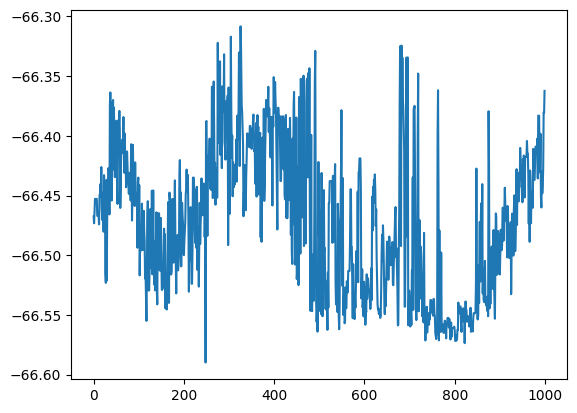

In [21]:
plt.plot(history_state[0].logdensity)

In [22]:
RWState = history_state[0]
positions = RWState.position
df = pd.DataFrame(positions)



In [23]:
df

,M_MN,M_NFW,Mtot,a_MN,a_Plummer,r_s,t_end
0,3.948528e+10,3.242769e+11,25206.677734,2.244195,0.004284,6.576619,3.717011
1,3.977183e+10,3.201710e+11,25129.660156,2.443110,0.003025,5.570961,3.736902
2,4.077792e+10,3.195565e+11,25043.613281,2.272680,0.002351,5.461328,3.588461
3,4.264924e+10,3.279854e+11,25110.203125,2.429720,0.002147,6.942396,3.756644
4,4.264924e+10,3.279854e+11,25110.203125,2.429720,0.002147,6.942396,3.756644
...,...,...,...,...,...,...,...
995,4.917758e+10,4.061686e+11,30090.916016,1.845201,0.010592,7.448351,3.686266
996,4.816583e+10,4.091173e+11,29902.408203,1.328469,0.011063,7.956852,3.558942
997,4.743892e+10,4.150578e+11,29977.365234,1.408797,0.012134,5.699027,3.652939
998,4.632965e+10,4.203694e+11,29984.330078,1.120901,0.012242,4.953636,3.697476


Parameter $M_{MN}$ [M$_\odot$] in chain MCMC Posterior is not constrained
Parameter $M_{NFW}$ [M$_\odot$] in chain MCMC Posterior is not constrained
Parameter $M_{Plummer}$ [M$_\odot$] in chain MCMC Posterior is not constrained
Parameter $a_{Plummer}$ [kpc] in chain MCMC Posterior is not constrained
Parameter $r_s$ [kpc] in chain MCMC Posterior is not constrained


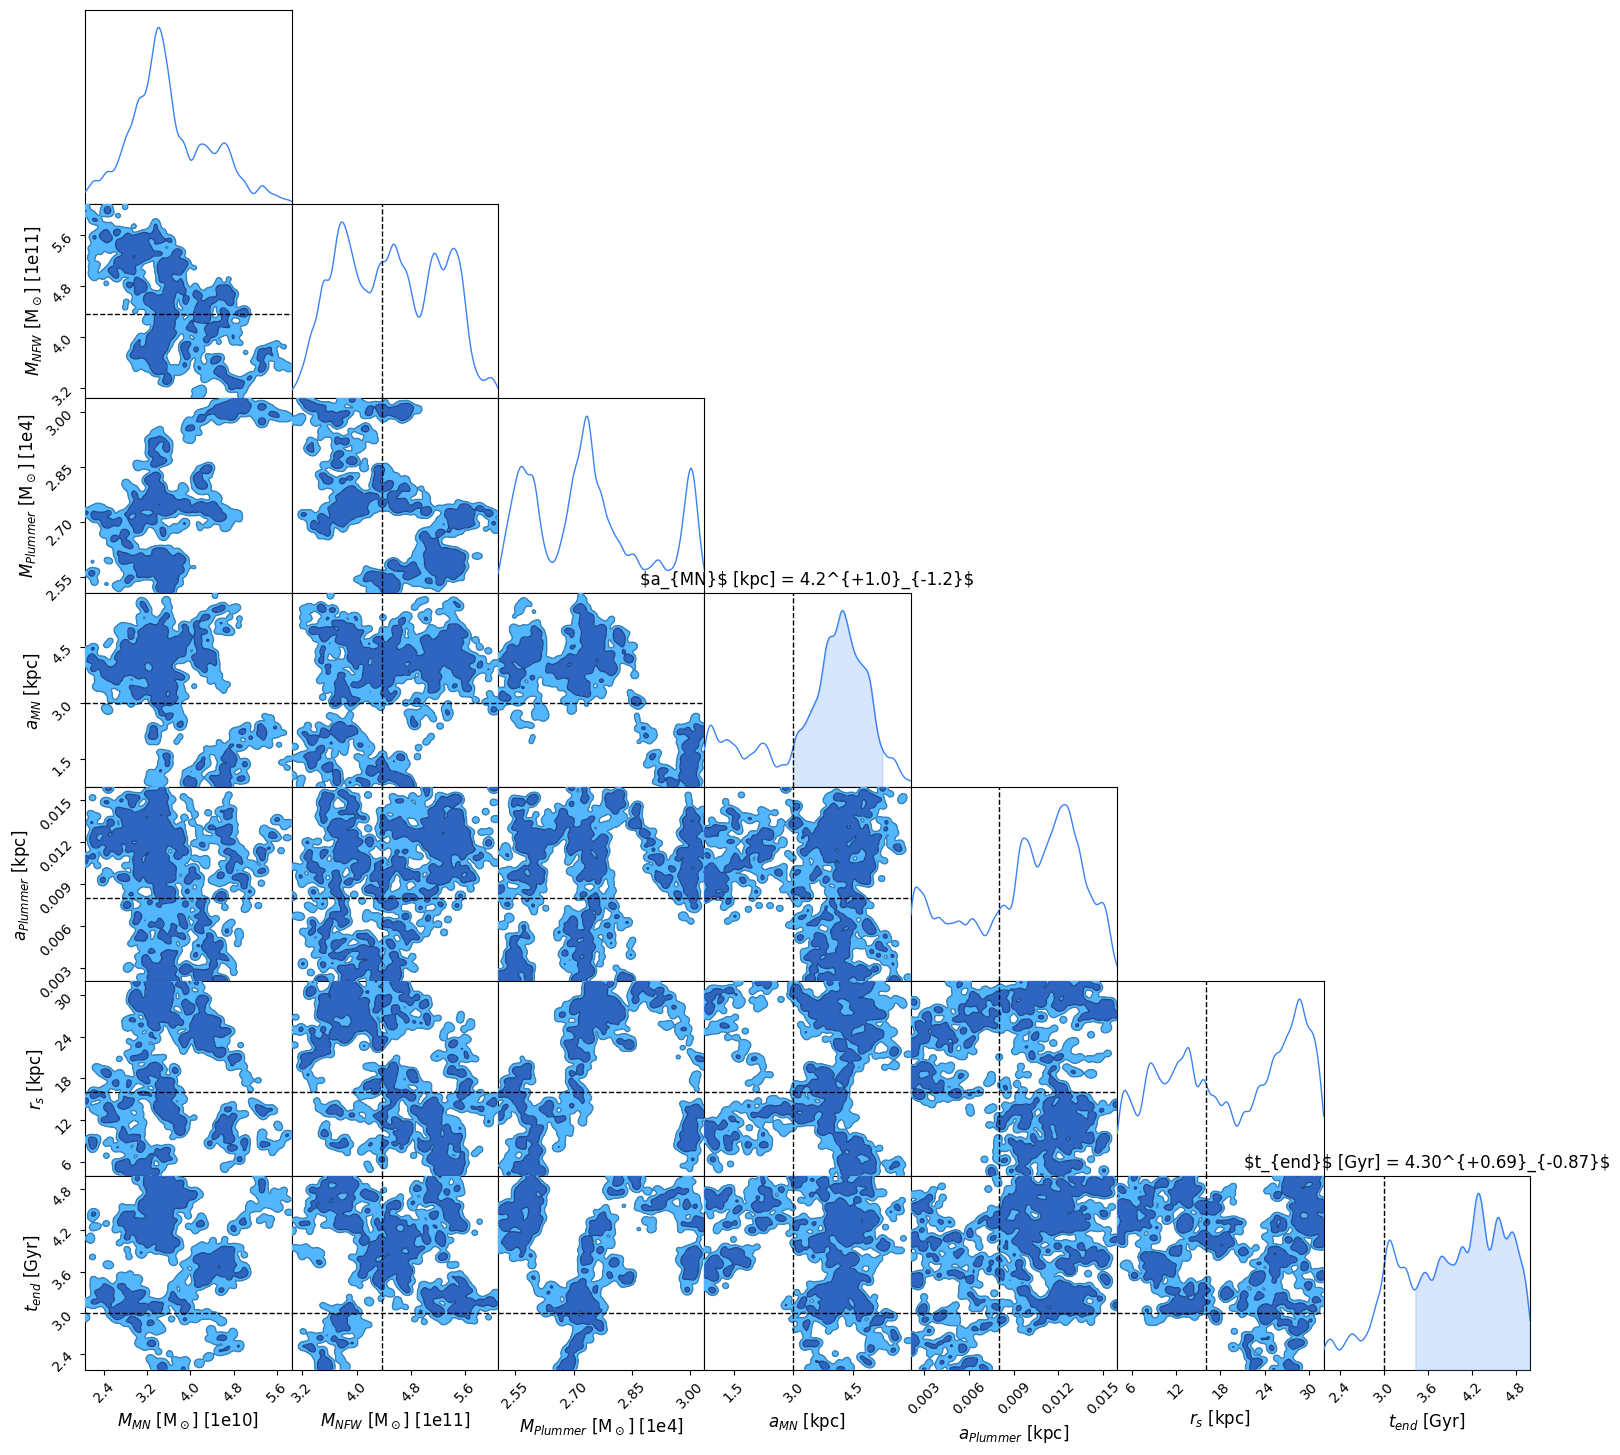

MCMC Summary (after burn-in):
Number of samples: 900
Parameter means:
  $t_{end}$ [Gyr]: 3.617716e+10
  $M_{Plummer}$ [M$_\odot$]: 4.502412e+11
  $a_{Plummer}$ [kpc]: 2.743608e+04
  $M_{NFW}$ [M$_\odot$]: 3.612454e+00
  $r_s$ [kpc]: 9.597661e-03
  $M_{MN}$ [M$_\odot$]: 1.923338e+01
  $a_{MN}$ [kpc]: 3.879236e+00

Parameter std deviations:
  $t_{end}$ [Gyr]: 7.515736e+09
  $M_{Plummer}$ [M$_\odot$]: 7.167644e+10
  $a_{Plummer}$ [kpc]: 1.493632e+03
  $M_{NFW}$ [M$_\odot$]: 1.277823e+00
  $r_s$ [kpc]: 3.782106e-03
  $M_{MN}$ [M$_\odot$]: 8.396905e+00
  $a_{MN}$ [kpc]: 7.083049e-01


In [34]:
# Import ChainConsumer
from chainconsumer import Chain, ChainConsumer, Truth

# Extract positions from history and convert to DataFrame
HMCState = history_state[0]
positions = HMCState.position
df = pd.DataFrame(positions)
df.columns = ['$M_{MN}$ [M$_\\odot$]', '$M_{NFW}$ [M$_\\odot$]', '$M_{Plummer}$ [M$_\\odot$]', '$a_{MN}$ [kpc]', '$a_{Plummer}$ [kpc]', '$r_s$ [kpc]', '$t_{end}$ [Gyr]']

# Remove burn-in (first 1000 samples)
df_burned = df.iloc[100:].reset_index(drop=True)

# Define parameter names with LaTeX formatting
param_names = ['$t_{end}$ [Gyr]', '$M_{Plummer}$ [M$_\\odot$]', '$a_{Plummer}$ [kpc]', 
               '$M_{NFW}$ [M$_\\odot$]', '$r_s$ [kpc]', '$M_{MN}$ [M$_\\odot$]', '$a_{MN}$ [kpc]']
params_names = df.columns

# Create Chain object
chain = Chain(samples=df_burned, name="MCMC Posterior")

# Create ChainConsumer object
c = ChainConsumer()
c.add_chain(chain)

# Add true values if you want to compare
true_values_dict = {
    '$t_{end}$ [Gyr]': 3.0,
    '$M_{Plummer}$ [M$_\\odot$]': 10**4.05,
    '$a_{Plummer}$ [kpc]': 8.0 * 1e-3,
    '$M_{NFW}$ [M$_\\odot$]': 4.3683325e11,
    '$r_s$ [kpc]': 16.0,
    '$M_{MN}$ [M$_\\odot$]': 68_193_902_782.346756,
    '$a_{MN}$ [kpc]': 3.0
}

# Add truth values
truth = Truth(location=true_values_dict, name="True Parameters")
c.add_truth(truth)

# Create corner plot
fig = c.plotter.plot()
plt.show()

# Print summary statistics
print("MCMC Summary (after burn-in):")
print(f"Number of samples: {len(df_burned)}")
print(f"Parameter means:")
for i, param in enumerate(param_names):
    print(f"  {param}: {df_burned.iloc[:, i].mean():.6e}")

print(f"\nParameter std deviations:")
for i, param in enumerate(param_names):
    print(f"  {param}: {df_burned.iloc[:, i].std():.6e}")

# RMH Vectorized

In [ ]:
from blackjax.util import run_inference_algorithm

# Fix: Create a proper random step function instead of passing an array
def random_step_fn(rng_key, position):
    """Generate random step proposals for each parameter."""
    # Use different step sizes for different parameters based on their scale
    step_sizes = jnp.array([
        0.1,    # t_end (Gyr) - smaller steps
        100.0,  # Mtot (Msun) - larger steps for large values
        0.001,  # a_Plummer (kpc) - very small steps
        1e10,    # M_NFW (Msun) - large steps for large values  
        1.0,    # r_s (kpc)
        1e9,    # M_MN (Msun) - large steps for large values
        0.2,    # a_MN (kpc)
    ])
    
    # Generate random steps
    random_steps = jax.random.normal(rng_key, shape=(7,)) * step_sizes
    
    # Convert to dictionary format to match your position format
    step_dict = {
        't_end': random_steps[0],
        'Mtot': random_steps[1], 
        'a_Plummer': random_steps[2],
        'M_NFW': random_steps[3],
        'r_s': random_steps[4],
        'M_MN': random_steps[5],
        'a_MN': random_steps[6]
    }
    return step_dict

@partial(jit, static_argnames=['num_chains'])
def run_inference_vmap(rng_key, num_chains=2):
    rng_keys = jax.random.split(rng_key, num_chains)
    intial_positions = jax.vmap(draw_from_prior)(rng_keys)
    # print(intial_positions)
    

    def extract_single_position(idx):
        """Extract a single position dict from the vmapped result."""
        return {key: values[idx] for key, values in intial_positions.items()}
    
    run_inference_vmap = lambda i: run_inference_algorithm(
        rng_key=rng_keys[i],
        inference_algorithm=blackjax.additive_step_random_walk(
                                    logdensity_fn=evaluate_log_posterior,
                                    random_step=random_step_fn
                                ),
        num_steps=10000,
        initial_position=extract_single_position(i),
        progress_bar=False,
    )

    return jax.vmap(run_inference_vmap)(jnp.arange(num_chains))
  
print('start running chains')
history = run_inference_vmap(jax.random.PRNGKey(42), num_chains=10)

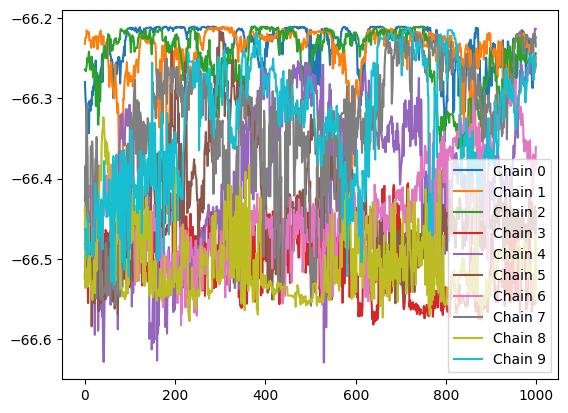

In [ ]:
for i in range(history[1][0].logdensity.shape[0]):
    plt.plot(history[1][0].logdensity[i], label=f'Chain {i}')
    plt.legend()

In [ ]:
def convert_multichain_to_dataframe_filtered(positions_dict, is_accepted_mask):
    """Convert dictionary of [num_chains, num_samples] arrays to DataFrame, filtering by acceptance."""
    
    all_samples = []
    num_chains = positions_dict['t_end'].shape[0]
    num_samples = positions_dict['t_end'].shape[1]
    
    print(f"Original samples: {num_chains} chains × {num_samples} samples = {num_chains * num_samples}")
    
    for chain_id in range(num_chains):
        # Get acceptance mask for this chain
        chain_accepted = is_accepted_mask[chain_id, :]  # Boolean mask for this chain
        
        # Extract samples for this chain
        chain_data = {}
        for param_name, values in positions_dict.items():
            # Only keep accepted samples
            chain_data[param_name] = values[chain_id, chain_accepted]
        
        # Count accepted samples for this chain
        n_accepted = jnp.sum(chain_accepted)
        print(f"  Chain {chain_id}: {n_accepted}/{num_samples} accepted ({n_accepted/num_samples*100:.1f}%)")
        
        # Create DataFrame for this chain (only accepted samples)
        if n_accepted > 0:  # Only add if there are accepted samples
            df_chain = pd.DataFrame(chain_data)
            df_chain['chain_id'] = chain_id
            df_chain['original_sample_id'] = jnp.where(chain_accepted)[0]  # Track original indices
            
            all_samples.append(df_chain)
    
    if not all_samples:
        print("⚠️ Warning: No accepted samples found!")
        return pd.DataFrame()
    
    # Combine all chains
    combined_df = pd.concat(all_samples, ignore_index=True)
    total_accepted = len(combined_df)
    total_original = num_chains * num_samples
    
    print(f"📊 Total accepted samples: {total_accepted}/{total_original} ({total_accepted/total_original*100:.1f}%)")
    
    return combined_df

# Use the filtered conversion
positions = history[1][0].position
is_accepted = history[1][1].is_accepted

# Convert with filtering
df_all_filtered = convert_multichain_to_dataframe_filtered(positions, is_accepted)

# Apply additional burn-in and thinning if needed
burn_in = 50  # Fewer since we already filtered by acceptance
thin_factor = 2  # Less thinning since we have fewer samples

if len(df_all_filtered) > 0:
    df_processed = df_all_filtered[
        (df_all_filtered['original_sample_id'] >= burn_in) & 
        (df_all_filtered['original_sample_id'] % thin_factor == 0)
    ].copy()
    
    # Remove metadata columns for plotting
    df_plot = df_processed.drop(['chain_id', 'original_sample_id'], axis=1)
    
    # Rename columns for nice LaTeX formatting
    df_plot.columns = ['$M_{MN}$ [M$_\\odot$]', '$M_{NFW}$ [M$_\\odot$]', '$M_{Plummer}$ [M$_\\odot$]', '$a_{MN}$ [kpc]', '$a_{Plummer}$ [kpc]', '$r_s$ [kpc]', '$t_{end}$ [Gyr]']
    
    print(f"📈 Final samples for plotting: {len(df_plot)}")
else:
    print("❌ No samples available for plotting after filtering!")

Original samples: 10 chains × 1000 samples = 10000
  Chain 0: 849/1000 accepted (84.9%)
  Chain 1: 841/1000 accepted (84.1%)
  Chain 2: 826/1000 accepted (82.6%)
  Chain 3: 827/1000 accepted (82.7%)
  Chain 4: 861/1000 accepted (86.1%)
  Chain 5: 910/1000 accepted (91.0%)
  Chain 6: 871/1000 accepted (87.1%)
  Chain 7: 881/1000 accepted (88.1%)
  Chain 8: 832/1000 accepted (83.2%)
  Chain 9: 811/1000 accepted (81.1%)
📊 Total accepted samples: 8509/10000 (85.1%)
📈 Final samples for plotting: 4022


Original samples: 10 chains × 1000 samples = 10000
  Chain 0: 849/1000 accepted (84.9%)
  Chain 1: 841/1000 accepted (84.1%)
  Chain 2: 826/1000 accepted (82.6%)
  Chain 3: 827/1000 accepted (82.7%)
  Chain 4: 861/1000 accepted (86.1%)
  Chain 5: 910/1000 accepted (91.0%)
  Chain 6: 871/1000 accepted (87.1%)
  Chain 7: 881/1000 accepted (88.1%)
  Chain 8: 832/1000 accepted (83.2%)
  Chain 9: 811/1000 accepted (81.1%)
📊 Total accepted samples: 8509/10000 (85.1%)
📈 Final samples for plotting: 429
🎨 Creating corner plot...


Parameter $M_{MN}$ [M$_\odot$] in chain MCMC Posterior (Filtered) is not constrained
Parameter $M_{NFW}$ [M$_\odot$] in chain MCMC Posterior (Filtered) is not constrained
Parameter $M_{Plummer}$ [M$_\odot$] in chain MCMC Posterior (Filtered) is not constrained
Parameter $a_{MN}$ [kpc] in chain MCMC Posterior (Filtered) is not constrained
Parameter $a_{Plummer}$ [kpc] in chain MCMC Posterior (Filtered) is not constrained
Parameter $t_{end}$ [Gyr] in chain MCMC Posterior (Filtered) is not constrained


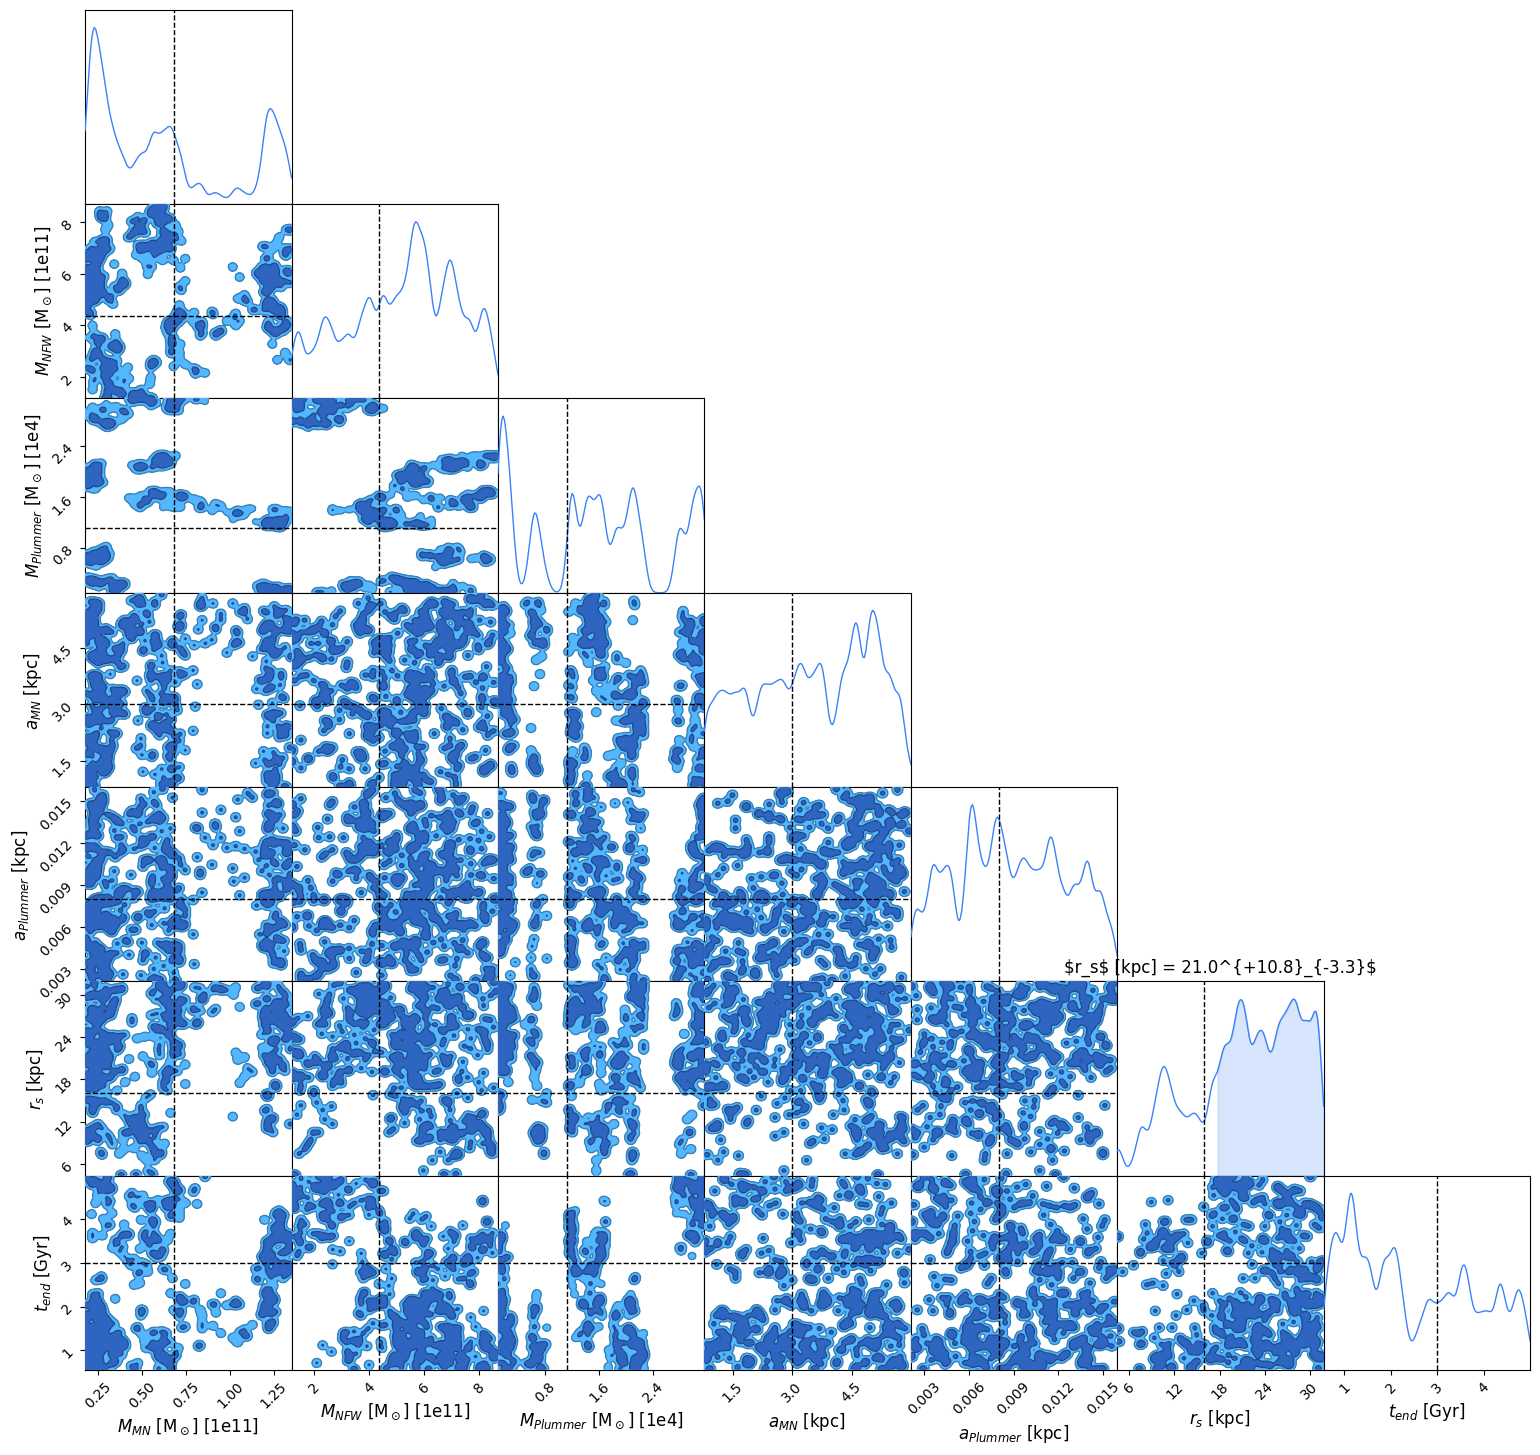


📊 MCMC Summary (filtered accepted samples):
Number of samples: 429
Number of chains: 10

Parameter estimates (mean ± std):
------------------------------------------------------------
$M_{MN}$ [M$_\odot$]: 6.234469e+10 ± 3.873298e+10
True value          : 3.000000e+00
Bias (σ)            : 1.61
------------------------------------------------------------
$M_{NFW}$ [M$_\odot$]: 5.202538e+11 ± 1.952753e+11
True value          : 1.122018e+04
Bias (σ)            : 2.66
------------------------------------------------------------
$M_{Plummer}$ [M$_\odot$]: 1.528792e+04 ± 9.733614e+03
True value          : 8.000000e-03
Bias (σ)            : 1.57
------------------------------------------------------------
$a_{MN}$ [kpc]      : 3.498124e+00 ± 1.459739e+00
True value          : 4.368332e+11
Bias (σ)            : -299254415360.00
------------------------------------------------------------
$a_{Plummer}$ [kpc] : 8.869259e-03 ± 3.687890e-03
True value          : 1.600000e+01
Bias (σ)            

In [ ]:
def convert_multichain_to_dataframe_filtered(positions_dict, is_accepted_mask):
    """Convert dictionary of [num_chains, num_samples] arrays to DataFrame, filtering by acceptance."""
    
    all_samples = []
    num_chains = positions_dict['t_end'].shape[0]
    num_samples = positions_dict['t_end'].shape[1]
    
    print(f"Original samples: {num_chains} chains × {num_samples} samples = {num_chains * num_samples}")
    
    for chain_id in range(num_chains):
        # Get acceptance mask for this chain
        chain_accepted = is_accepted_mask[chain_id, :]  # Boolean mask for this chain
        
        # Extract samples for this chain
        chain_data = {}
        for param_name, values in positions_dict.items():
            # Only keep accepted samples
            chain_data[param_name] = values[chain_id, chain_accepted]
        
        # Count accepted samples for this chain
        n_accepted = jnp.sum(chain_accepted)
        print(f"  Chain {chain_id}: {n_accepted}/{num_samples} accepted ({n_accepted/num_samples*100:.1f}%)")
        
        # Create DataFrame for this chain (only accepted samples)
        if n_accepted > 0:  # Only add if there are accepted samples
            df_chain = pd.DataFrame(chain_data)
            df_chain['chain_id'] = chain_id
            df_chain['original_sample_id'] = jnp.where(chain_accepted)[0]  # Track original indices
            
            all_samples.append(df_chain)
    
    if not all_samples:
        print("⚠️ Warning: No accepted samples found!")
        return pd.DataFrame()
    
    # Combine all chains
    combined_df = pd.concat(all_samples, ignore_index=True)
    total_accepted = len(combined_df)
    total_original = num_chains * num_samples
    
    print(f"📊 Total accepted samples: {total_accepted}/{total_original} ({total_accepted/total_original*100:.1f}%)")
    
    return combined_df

# Use the filtered conversion
positions = history[1][0].position
is_accepted = history[1][1].is_accepted

# Convert with filtering
df_all_filtered = convert_multichain_to_dataframe_filtered(positions, is_accepted)

# Apply additional burn-in and thinning if needed
burn_in = 500  # Fewer since we already filtered by acceptance
thin_factor = 10  # Less thinning since we have fewer samples

if len(df_all_filtered) > 0:
    df_processed = df_all_filtered[
        (df_all_filtered['original_sample_id'] >= burn_in) & 
        (df_all_filtered['original_sample_id'] % thin_factor == 0)
    ].copy()
    
    # Remove metadata columns for plotting
    df_plot = df_processed.drop(['chain_id', 'original_sample_id'], axis=1)
    
    # Rename columns for nice LaTeX formatting
    df_plot.columns = ['$M_{MN}$ [M$_\odot$]', '$M_{NFW}$ [M$_\odot$]', '$M_{Plummer}$ [M$_\odot$]', '$a_{MN}$ [kpc]', '$a_{Plummer}$ [kpc]', '$r_s$ [kpc]', '$t_{end}$ [Gyr]']
    
    print(f"📈 Final samples for plotting: {len(df_plot)}")
    
    # Create ChainConsumer plot with true values
    from chainconsumer import Chain, ChainConsumer, Truth
    
    # Create Chain object
    chain = Chain(samples=df_plot, name="MCMC Posterior (Filtered)")
    
    # Create ChainConsumer object
    c = ChainConsumer()
    c.add_chain(chain)
    
    # Add true values
    true_values_dict = {
        '$t_{end}$ [Gyr]': 3.0,
        '$M_{Plummer}$ [M$_\odot$]': 10**4.05,
        '$a_{Plummer}$ [kpc]': 8.0 * 1e-3,
        '$M_{NFW}$ [M$_\odot$]': 4.3683325e11,
        '$r_s$ [kpc]': 16.0,
        '$M_{MN}$ [M$_\odot$]': 68_193_902_782.346756,
        '$a_{MN}$ [kpc]': 3.0
    }
    
    truth = Truth(location=true_values_dict, name="True Parameters")
    c.add_truth(truth)
    
    # Create corner plot
    print("🎨 Creating corner plot...")
    fig = c.plotter.plot()
    plt.show()
    
    # Print summary statistics
    print("\n📊 MCMC Summary (filtered accepted samples):")
    print(f"Number of samples: {len(df_plot)}")
    print(f"Number of chains: {df_processed['chain_id'].nunique()}")
    
    # Calculate parameter statistics
    param_names = ['$M_{MN}$ [M$_\odot$]', '$M_{NFW}$ [M$_\odot$]', '$M_{Plummer}$ [M$_\odot$]', '$a_{MN}$ [kpc]', '$a_{Plummer}$ [kpc]', '$r_s$ [kpc]', '$t_{end}$ [Gyr]']
    
    print("\nParameter estimates (mean ± std):")
    print("-" * 60)
    for i, param in enumerate(param_names):
        col_name = df_plot.columns[i]
        mean_val = df_plot[col_name].mean()
        std_val = df_plot[col_name].std()
        true_val = list(true_values_dict.values())[i]
        
        print(f"{param:20s}: {mean_val:.6e} ± {std_val:.6e}")
        print(f"{'True value':20s}: {true_val:.6e}")
        print(f"{'Bias (σ)':20s}: {(mean_val - true_val) / std_val:.2f}")
        print("-" * 60)
    
else:
    print("❌ No samples available for plotting after filtering!")

# NUTS

In [6]:


# Fix: Create a proper random step function instead of passing an array
def random_step_fn(rng_key, position):
    """Generate random step proposals for each parameter."""
    # Use different step sizes for different parameters based on their scale
    step_sizes = jnp.array([
        0.1,    # t_end (Gyr) - smaller steps
        100.0,  # Mtot (Msun) - larger steps for large values
        0.001,  # a_Plummer (kpc) - very small steps
        1e10,    # M_NFW (Msun) - large steps for large values  
        1.0,    # r_s (kpc)
        1e9,    # M_MN (Msun) - large steps for large values
        0.2,    # a_MN (kpc)
    ])
    
    # Generate random steps
    random_steps = jax.random.normal(rng_key, shape=(7,)) * step_sizes
    
    # Convert to dictionary format to match your position format
    step_dict = {
        't_end': random_steps[0],
        'Mtot': random_steps[1], 
        'a_Plummer': random_steps[2],
        'M_NFW': random_steps[3],
        'r_s': random_steps[4],
        'M_MN': random_steps[5],
        'a_MN': random_steps[6]
    }
    return step_dict

# Build the kernel
# rmh = blackjax.additive_step_random_walk(
#     logdensity_fn=evaluate_log_posterior,
#     random_step=random_step_fn
# )

# Scale-aware mass matrix based on parameter magnitudes
param_scales = jnp.array([
    1.0,        # t_end (Gyr) - order 1
    1e4,        # Mtot (Msun) - order 10^4
    1e-3,       # a_Plummer (kpc) - order 10^-3
    1e11,       # M_NFW (Msun) - order 10^11
    10.0,       # r_s (kpc) - order 10
    1e11,       # M_MN (Msun) - order 10^11
    1.0,        # a_MN (kpc) - order 1
])

# Create inverse mass matrix with scale-appropriate variances
scale_factors = 0.01 * param_scales  # 1% of typical scale as step size
inverse_mass_matrix = jnp.diag(scale_factors**2)
# # Build the kernel
step_size = 1e-5
nuts = blackjax.nuts(evaluate_log_posterior, step_size, inverse_mass_matrix)

# Initialize the state
initial_position = draw_from_prior(jax.random.PRNGKey(42))
state = nuts.init(initial_position)


from blackjax.util import run_inference_algorithm

final_state, history_state = run_inference_algorithm(
    rng_key=jax.random.PRNGKey(0),
    inference_algorithm=nuts,
    num_steps=10,
    initial_state=state,
    progress_bar=True,
)

In [7]:
history_state

(HMCState(position={'M_MN': Array([4.1230295e+10, 4.1230295e+10, 4.1230295e+10, 4.1230295e+10,
        4.1230295e+10, 4.1230295e+10, 4.1230295e+10, 4.1230295e+10,
        4.1230295e+10, 4.1230295e+10], dtype=float32), 'M_NFW': Array([3.0997814e+11, 3.0997814e+11, 3.0997814e+11, 3.0997814e+11,
        3.0997814e+11, 3.0997814e+11, 3.0997814e+11, 3.0997814e+11,
        3.0997814e+11, 3.0997814e+11], dtype=float32), 'Mtot': Array([25126.693, 25126.693, 25126.693, 25126.693, 25126.693, 25126.693,
        25126.693, 25126.693, 25126.693, 25126.693], dtype=float32), 'a_MN': Array([2.4178643, 2.4178643, 2.4178643, 2.4178643, 2.4178643, 2.4178643,
        2.4178643, 2.4178643, 2.4178643, 2.4178643], dtype=float32), 'a_Plummer': Array([0.00454372, 0.00454372, 0.00454372, 0.00454372, 0.00454372,
        0.00454372, 0.00454372, 0.00454372, 0.00454372, 0.00454372],      dtype=float32), 'r_s': Array([7.1004214, 7.1004214, 7.1004214, 7.1004214, 7.1004214, 7.1004214,
        7.1004214, 7.1004214, 7.1

Parameter $M_{MN}$ [M$_\odot$] in chain MCMC Posterior is not constrained
Parameter $M_{NFW}$ [M$_\odot$] in chain MCMC Posterior is not constrained
Parameter $M_{Plummer}$ [M$_\odot$] in chain MCMC Posterior is not constrained
Parameter $a_{Plummer}$ [kpc] in chain MCMC Posterior is not constrained
Parameter $r_s$ [kpc] in chain MCMC Posterior is not constrained


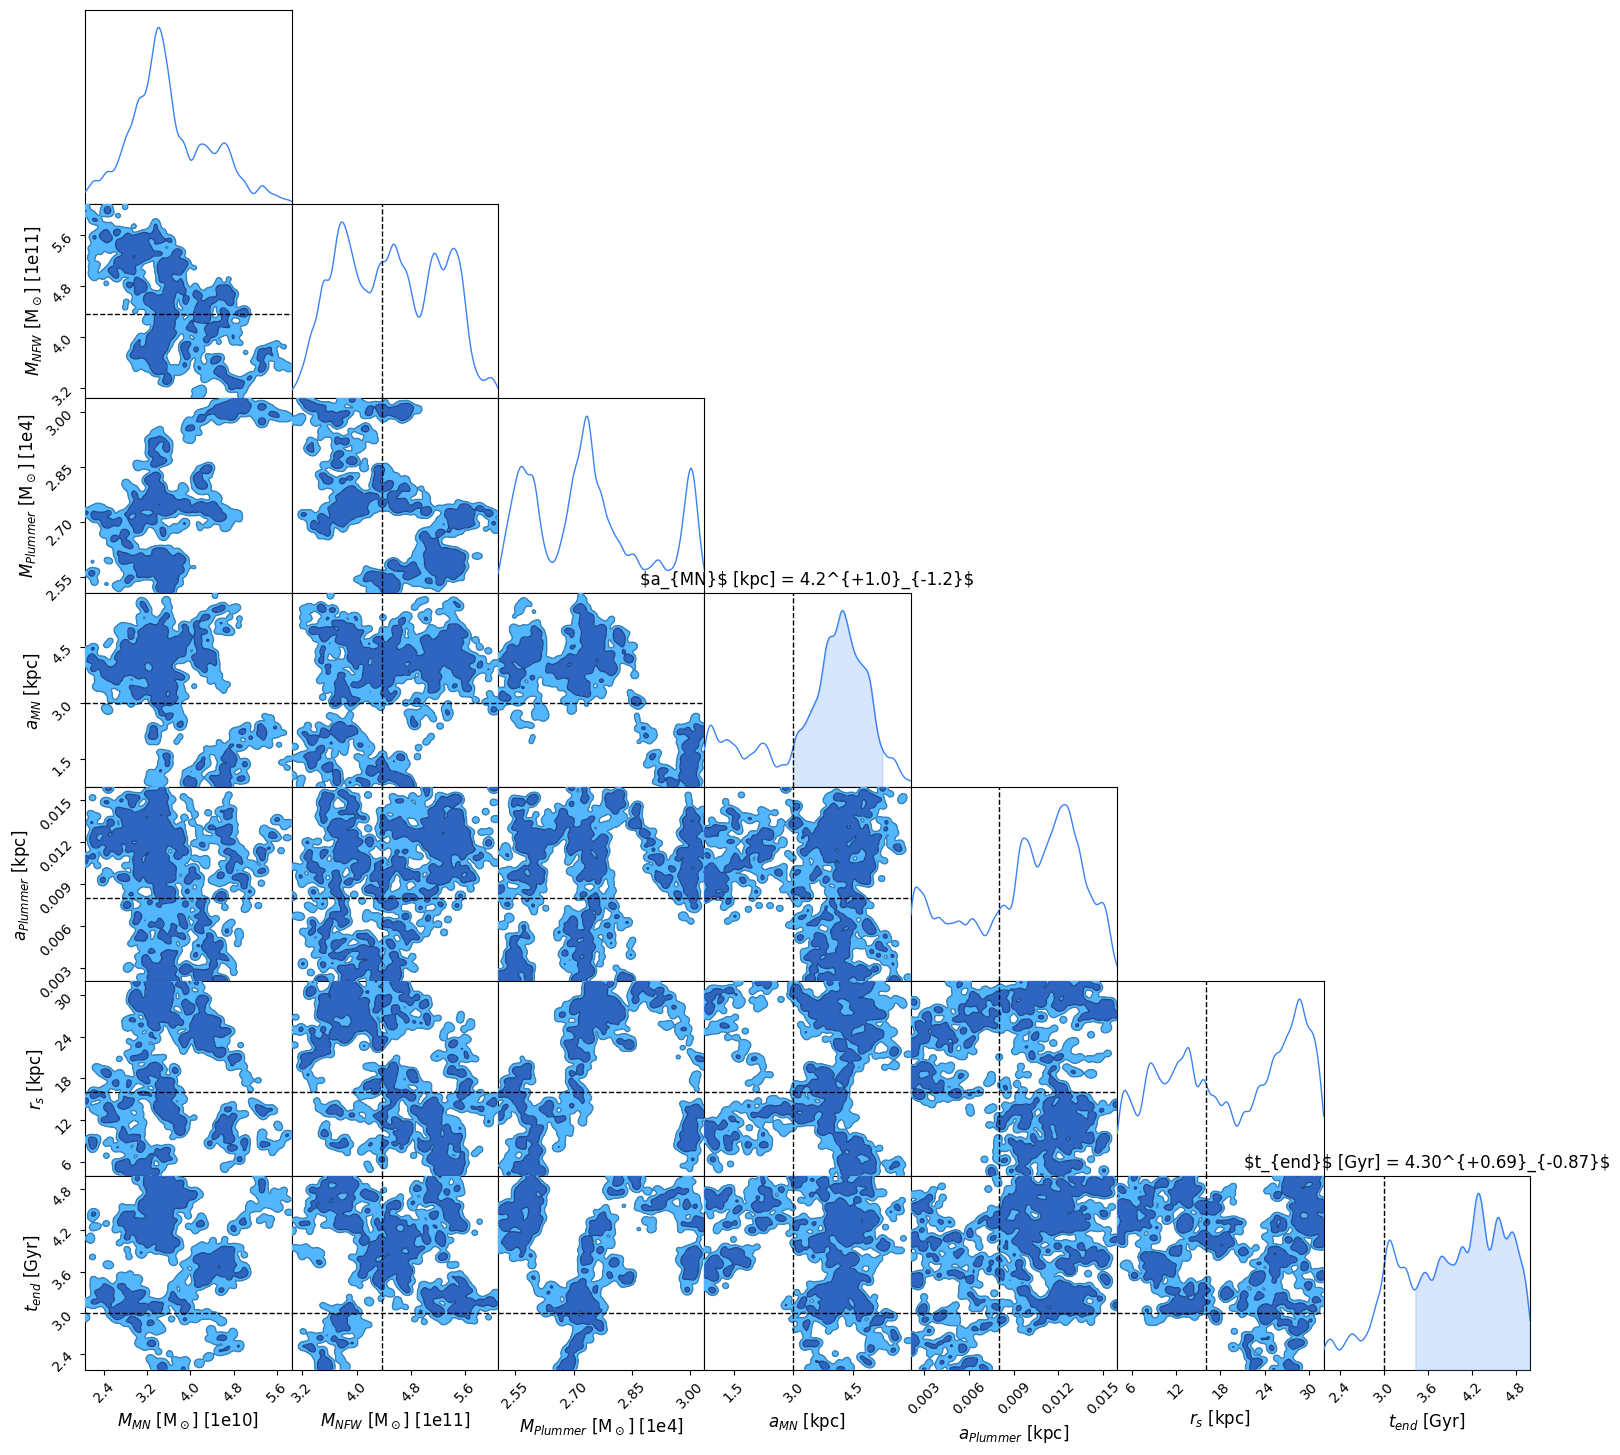

MCMC Summary (after burn-in):
Number of samples: 900
Parameter means:
  $t_{end}$ [Gyr]: 3.617716e+10
  $M_{Plummer}$ [M$_\odot$]: 4.502412e+11
  $a_{Plummer}$ [kpc]: 2.743608e+04
  $M_{NFW}$ [M$_\odot$]: 3.612454e+00
  $r_s$ [kpc]: 9.597661e-03
  $M_{MN}$ [M$_\odot$]: 1.923338e+01
  $a_{MN}$ [kpc]: 3.879236e+00

Parameter std deviations:
  $t_{end}$ [Gyr]: 7.515736e+09
  $M_{Plummer}$ [M$_\odot$]: 7.167644e+10
  $a_{Plummer}$ [kpc]: 1.493632e+03
  $M_{NFW}$ [M$_\odot$]: 1.277823e+00
  $r_s$ [kpc]: 3.782106e-03
  $M_{MN}$ [M$_\odot$]: 8.396905e+00
  $a_{MN}$ [kpc]: 7.083049e-01


In [25]:
# Import ChainConsumer
from chainconsumer import Chain, ChainConsumer, Truth

# Extract positions from history and convert to DataFrame
HMCState = history_state[0]
positions = HMCState.position
df = pd.DataFrame(positions)
df.columns = ['$M_{MN}$ [M$_\\odot$]', '$M_{NFW}$ [M$_\\odot$]', '$M_{Plummer}$ [M$_\\odot$]', '$a_{MN}$ [kpc]', '$a_{Plummer}$ [kpc]', '$r_s$ [kpc]', '$t_{end}$ [Gyr]']

# Remove burn-in (first 1000 samples)
df_burned = df.iloc[100:].reset_index(drop=True)

# Define parameter names with LaTeX formatting
param_names = ['$t_{end}$ [Gyr]', '$M_{Plummer}$ [M$_\\odot$]', '$a_{Plummer}$ [kpc]', 
               '$M_{NFW}$ [M$_\\odot$]', '$r_s$ [kpc]', '$M_{MN}$ [M$_\\odot$]', '$a_{MN}$ [kpc]']
params_names = df.columns

# Create Chain object
chain = Chain(samples=df_burned, name="MCMC Posterior")

# Create ChainConsumer object
c = ChainConsumer()
c.add_chain(chain)

# Add true values if you want to compare
true_values_dict = {
    '$t_{end}$ [Gyr]': 3.0,
    '$M_{Plummer}$ [M$_\\odot$]': 10**4.05,
    '$a_{Plummer}$ [kpc]': 8.0 * 1e-3,
    '$M_{NFW}$ [M$_\\odot$]': 4.3683325e11,
    '$r_s$ [kpc]': 16.0,
    '$M_{MN}$ [M$_\\odot$]': 68_193_902_782.346756,
    '$a_{MN}$ [kpc]': 3.0
}

# Add truth values
truth = Truth(location=true_values_dict, name="True Parameters")
c.add_truth(truth)

# Create corner plot
fig = c.plotter.plot()
plt.show()

# Print summary statistics
print("MCMC Summary (after burn-in):")
print(f"Number of samples: {len(df_burned)}")
print(f"Parameter means:")
for i, param in enumerate(param_names):
    print(f"  {param}: {df_burned.iloc[:, i].mean():.6e}")

print(f"\nParameter std deviations:")
for i, param in enumerate(param_names):
    print(f"  {param}: {df_burned.iloc[:, i].std():.6e}")

In [26]:
# Use BlackJAX's automatic adaptation
from blackjax import window_adaptation


# Set up adaptation parameters
num_warmup = 10
num_sampling = 50

# Create the adaptation algorithm
adapt = window_adaptation(
    algorithm=blackjax.nuts,
    logdensity_fn=evaluate_log_posterior,
    is_mass_matrix_diagonal=True,  # Use diagonal mass matrix
    initial_step_size=1e-3,
    target_acceptance_rate=0.8,
)

# Initialize with array format
initial_position_dict = draw_from_prior(jax.random.PRNGKey(42))
initial_position_array = initial_position_dict

# Run adaptation
rng_key = jax.random.PRNGKey(0)
(state, parameters), _ = adapt.run(
    rng_key, 
    initial_position_array, 
    num_steps=num_warmup
)

# print("Adapted step size:", parameters.step_size)
# print("Adapted mass matrix diagonal:", jnp.diag(parameters.inverse_mass_matrix))

# Now use the adapted parameters for sampling
nuts = blackjax.nuts(
    logdensity_fn=evaluate_log_posterior, 
    step_size=parameters['step_size'], 
    inverse_mass_matrix=parameters['inverse_mass_matrix'],
)
from blackjax.util import run_inference_algorithm

# Continue sampling with adapted parameters
final_state, history = run_inference_algorithm(
    rng_key=jax.random.fold_in(rng_key, num_warmup),
    inference_algorithm=nuts,
    num_steps=num_sampling,
    initial_state=state,
    progress_bar=True,
)

In [27]:
history

(HMCState(position={'M_MN': Array([4.1230295e+10, 4.1230295e+10, 4.1230295e+10, 4.1230295e+10,
        4.1230295e+10, 4.1230295e+10, 4.1230295e+10, 4.1230295e+10,
        4.1230295e+10, 4.1230295e+10, 4.1230295e+10, 4.1230295e+10,
        4.1230295e+10, 4.1230295e+10, 4.1230295e+10, 4.1230295e+10,
        4.1230295e+10, 4.1230295e+10, 4.1230295e+10, 4.1230295e+10,
        4.1230295e+10, 4.1230295e+10, 4.1230295e+10, 4.1230295e+10,
        4.1230295e+10, 4.1230295e+10, 4.1230295e+10, 4.1230295e+10,
        4.1230295e+10, 4.1230295e+10, 4.1230295e+10, 4.1230295e+10,
        4.1230295e+10, 4.1230295e+10, 4.1230295e+10, 4.1230295e+10,
        4.1230295e+10, 4.1230295e+10, 4.1230295e+10, 4.1230295e+10,
        4.1230295e+10, 4.1230295e+10, 4.1230295e+10, 4.1230295e+10,
        4.1230295e+10, 4.1230295e+10, 4.1230295e+10, 4.1230295e+10,
        4.1230295e+10, 4.1230295e+10], dtype=float32), 'M_NFW': Array([3.0997814e+11, 3.0997814e+11, 3.0997814e+11, 3.0997814e+11,
        3.0997814e+11, 3.0

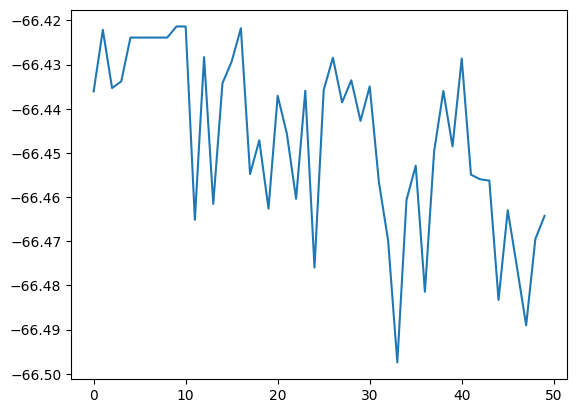

In [29]:
plt.plot(history[0].logdensity)

In [ ]:
# Import ChainConsumer
from chainconsumer import Chain, ChainConsumer, Truth

# Extract positions from history and convert to DataFrame
RWState = history[0]
positions = RWState.position
df = pd.DataFrame(positions)
df.columns = ['$M_{MN}$ [M$_\\odot$]', '$M_{NFW}$ [M$_\\odot$]', '$M_{Plummer}$ [M$_\\odot$]', '$a_{MN}$ [kpc]', '$a_{Plummer}$ [kpc]', '$r_s$ [kpc]', '$t_{end}$ [Gyr]']

# Remove burn-in (first 1000 samples)
df_burned = df.iloc[:].reset_index(drop=True)

# Define parameter names with LaTeX formatting
param_names = ['$t_{end}$ [Gyr]', '$M_{Plummer}$ [M$_\\odot$]', '$a_{Plummer}$ [kpc]', 
               '$M_{NFW}$ [M$_\\odot$]', '$r_s$ [kpc]', '$M_{MN}$ [M$_\\odot$]', '$a_{MN}$ [kpc]']
params_names = df.columns

# Create Chain object
chain = Chain(samples=df_burned, name="MCMC Posterior")

# Create ChainConsumer object
c = ChainConsumer()
c.add_chain(chain)

# Add true values if you want to compare
true_values_dict = {
    '$t_{end}$ [Gyr]': 3.0,
    '$M_{Plummer}$ [M$_\\odot$]': 10**4.05,
    '$a_{Plummer}$ [kpc]': 8.0 * 1e-3,
    '$M_{NFW}$ [M$_\\odot$]': 4.3683325e11,
    '$r_s$ [kpc]': 16.0,
    '$M_{MN}$ [M$_\\odot$]': 68_193_902_782.346756,
    '$a_{MN}$ [kpc]': 3.0
}

# Add truth values
truth = Truth(location=true_values_dict, name="True Parameters")
c.add_truth(truth)

# Create corner plot
fig = c.plotter.plot()
plt.show()

# Print summary statistics
print("MCMC Summary (after burn-in):")
print(f"Number of samples: {len(df_burned)}")
print(f"Parameter means:")
for i, param in enumerate(param_names):
    print(f"  {param}: {df_burned.iloc[:, i].mean():.6e}")

print(f"\nParameter std deviations:")
for i, param in enumerate(param_names):
    print(f"  {param}: {df_burned.iloc[:, i].std():.6e}")

ValueError: Too many bins for data range. Cannot create 2000 finite-sized bins.